In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Users/AIRA/OneDrive/Desktop/241BCADA06/Desktop/ML PROJECT/workspace/credit_card_fraud.csv")   # change path if needed

print(df.shape)
df.head()
df.info()
df.describe()
print("Missing values:")
print(df.isnull().sum())

(339607, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  339607 non-null  object 
 1   merchant               339607 non-null  object 
 2   category               339607 non-null  object 
 3   amt                    339607 non-null  float64
 4   city                   339607 non-null  object 
 5   state                  339607 non-null  object 
 6   lat                    339607 non-null  float64
 7   long                   339607 non-null  float64
 8   city_pop               339607 non-null  int64  
 9   job                    339607 non-null  object 
 10  dob                    339607 non-null  object 
 11  trans_num              339607 non-null  object 
 12  merch_lat              339607 non-null  float64
 13  merch_long             339607 non-null  float64
 14  is_fraud               

In [3]:
print("\nDuplicate rows:", df.duplicated().sum())
print("Unique trans_num:", df['trans_num'].nunique(), "| Total rows:", len(df))


Duplicate rows: 0
Unique trans_num: 339607 | Total rows: 339607


In [5]:
print("\nUnique values per column:")
print(df.nunique())
# dates are strings -> convert to datetime
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])


Unique values per column:
trans_date_trans_time    338504
merchant                    693
category                     14
amt                       32112
city                        176
state                        13
lat                         183
long                        183
city_pop                    174
job                         163
dob                         187
trans_num                339607
merch_lat                335608
merch_long               337263
is_fraud                      2
dtype: int64


In [7]:
for col in ['merchant', 'category', 'city', 'job']:
    df[col] = df[col].str.strip()
df['category'] = df['category'].str.lower()
df['state'] = df['state'].str.upper()

# trans_num is just an ID, it has no predictive value
df = df.drop('trans_num', axis=1)

trans_date_trans_time    datetime64[ns]
merchant                         object
category                         object
amt                             float64
city                             object
state                            object
lat                             float64
long                            float64
city_pop                          int64
job                              object
dob                      datetime64[ns]
merch_lat                       float64
merch_long                      float64
is_fraud                          int64
dtype: object


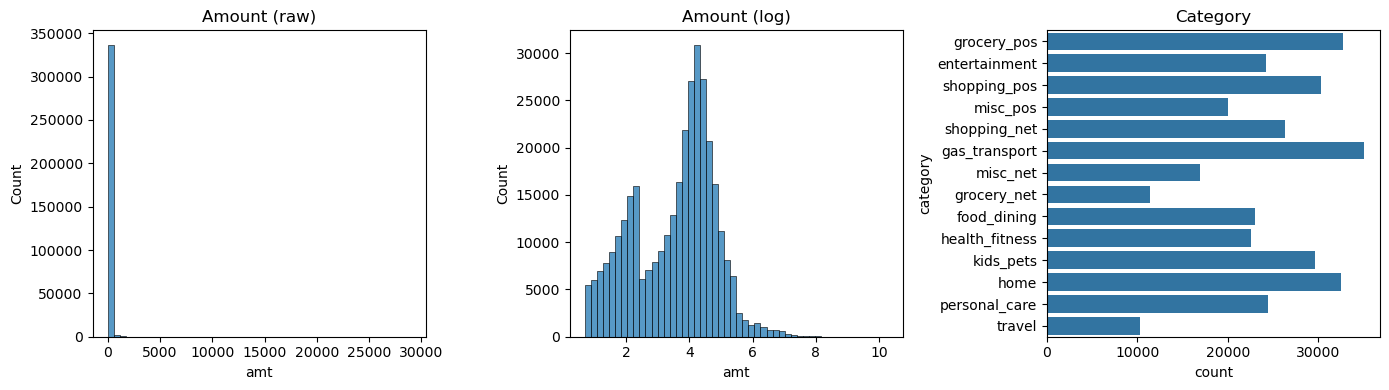

In [9]:
print(df.dtypes)
plt.figure(figsize=(14,4))
plt.subplot(1,3,1); sns.histplot(df['amt'], bins=50); plt.title("Amount (raw)")
plt.subplot(1,3,2); sns.histplot(np.log1p(df['amt']), bins=50); plt.title("Amount (log)")
plt.subplot(1,3,3); sns.countplot(y='category', data=df); plt.title("Category")
plt.tight_layout(); plt.show()

In [11]:
print(df['amt'].describe())
print("Skewness:", df['amt'].skew())
print(df['category'].value_counts())
Q1 = df['amt'].quantile(0.25)
Q3 = df['amt'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

count    339607.000000
mean         70.577984
std         161.675242
min           1.000000
25%           9.600000
50%          46.460000
75%          83.350000
max       28948.900000
Name: amt, dtype: float64
Skewness: 40.30183785312848
category
gas_transport     35089
grocery_pos       32732
home              32516
shopping_pos      30329
kids_pets         29704
shopping_net      26379
personal_care     24406
entertainment     24222
food_dining       23038
health_fitness    22593
misc_pos          20024
misc_net          16898
grocery_net       11355
travel            10322
Name: count, dtype: int64


In [13]:
outliers = df[df['amt'] > upper]
print("Outlier limit:", round(upper, 2))
print("Outlier rows:", len(outliers))
print("Fraud rate in outliers:", round(outliers['is_fraud'].mean()*100, 2), "%")
print("Fraud rate overall  :", round(df['is_fraud'].mean()*100, 2), "%")
print(df['is_fraud'].value_counts())
print("Fraud %:", round(df['is_fraud'].mean()*100, 3))

Outlier limit: 193.98
Outlier rows: 18043
Fraud rate in outliers: 7.42 %
Fraud rate overall  : 0.52 %
is_fraud
0    337825
1      1782
Name: count, dtype: int64
Fraud %: 0.525


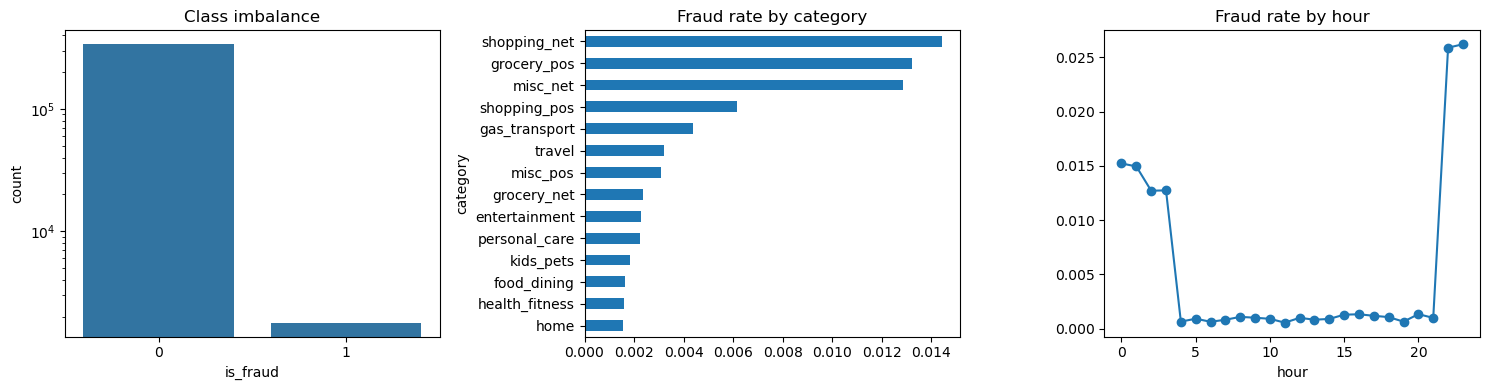

KeyError: 'is fraud'

In [17]:
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
sns.countplot(x='is_fraud', data=df); plt.yscale('log'); plt.title("Class imbalance")

plt.subplot(1,3,2)
df.groupby('category')['is_fraud'].mean().sort_values().plot(kind='barh')
plt.title("Fraud rate by category")

plt.subplot(1,3,3)
df['hour'] = df['trans_date_trans_time'].dt.hour
df.groupby('hour')['is_fraud'].mean().plot(marker='o')
plt.title("Fraud rate by hour")
plt.tight_layout(); plt.show()

print(df.groupby('is fraud')['amt'].mean())
plt.figure(figsize=(8,5))
sns.heatmap(df[['amt','lat','long','city_pop','merch_lat','merch_long','is_fraud']].corr(),
            annot=True, cmap='coolwarm')
plt.show()
# time features
df['hour']  = df['trans_date_trans_time'].dt.hour
df['day']   = df['trans_date_trans_time'].dt.dayofweek
df['month'] = df['trans_date_trans_time'].dt.month

In [19]:
# customer age at time of transaction
df['age'] = ((df['trans_date_trans_time'] - df['dob']).dt.days / 365).astype(int)

# distance between customer home and merchant
df['distance'] = np.sqrt((df['lat'] - df['merch_lat'])**2 +
                         (df['long'] - df['merch_long'])**2)

In [21]:
cap = df['amt'].quantile(0.999)
df['amt'] = df['amt'].clip(upper=cap)
df['log_amt'] = np.log1p(df['amt'])
print("Capped at:", round(cap, 2))

Capped at: 1587.23


In [23]:

# one-hot encode category
df = pd.get_dummies(df, columns=['category'], drop_first=True)

# drop columns we've already extracted information from
drop_cols = ['trans_date_trans_time','dob','merchant','city','state','job',
             'lat','long','merch_lat','merch_long','amt']
df_final = df.drop(columns=drop_cols)

print(df_final.shape)
print(df_final.columns.tolist())


(339607, 19)
['city_pop', 'is_fraud', 'hour', 'age', 'distance', 'log_amt', 'category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel']


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_final.drop('is_fraud', axis=1)
y = df_final['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)   # stratify keeps fraud % equal

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)  # fit on train
X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=X.columns)       # only transform test

X_train_scaled.assign(is_fraud=y_train.values).to_csv("train_clean.csv", index=False)
X_test_scaled.assign(is_fraud=y_test.values).to_csv("test_clean.csv", index=False)

print("Train:", X_train_scaled.shape, "| Test:", X_test_scaled.shape)
print("Train fraud %:", round(y_train.mean()*100, 3))
print("Test fraud %:", round(y_test.mean()*100, 3))

Train: (271685, 18) | Test: (67922, 18)
Train fraud %: 0.525
Test fraud %: 0.524


In [27]:
pd.set_option('display.max_columns', None)

print("="*60)
print("PROCESSED DATASET (after cleaning + feature engineering)")
print("="*60)
print("Shape:", df_final.shape)
print("Columns:", df_final.columns.tolist())
print()
display(df_final.head(10))

print("\n" + "="*60)
print("TRAIN SET (scaled, ready for model)")
print("="*60)
print("Shape:", X_train_scaled.shape)
display(X_train_scaled.assign(is_fraud=y_train.values).head(10))

PROCESSED DATASET (after cleaning + feature engineering)
Shape: (339607, 19)
Columns: ['city_pop', 'is_fraud', 'hour', 'age', 'distance', 'log_amt', 'category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel']



,city_pop,is_fraud,hour,age,distance,log_amt,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel
0,149,0,0,40,0.272310,4.684259,False,False,False,True,False,False,False,False,False,False,False,False,False
1,4154,0,0,56,0.975845,5.398660,False,False,False,False,False,False,False,False,False,False,False,False,False
2,589,0,0,73,0.298863,4.577696,False,False,False,True,False,False,False,False,False,False,False,False,False
3,899,0,0,51,0.705448,2.171337,False,False,False,False,False,False,False,False,False,False,False,True,False
4,471,0,0,51,0.850720,2.060514,False,False,False,False,False,False,False,False,True,False,False,False,False
5,4878,0,0,52,0.764488,4.513274,False,False,False,True,False,False,False,False,False,False,False,False,False
6,4005,0,0,73,0.724213,1.613430,False,False,False,False,False,False,False,False,False,False,False,True,False
7,597,0,0,57,0.845258,1.539015,False,False,False,False,False,False,False,False,False,False,True,False,False
8,46,0,0,31,0.850322,4.635990,False,True,False,False,False,False,False,False,False,False,False,False,False
9,85,0,0,34,0.507093,4.431650,False,False,False,True,False,False,False,False,False,False,False,False,False



TRAIN SET (scaled, ready for model)
Shape: (271685, 18)


,city_pop,hour,age,distance,log_amt,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,is_fraud
0,-0.360142,0.027640,-0.079355,1.069894,-0.214566,-0.270352,-0.338952,-0.18581,-0.326650,-0.26699,-0.325649,3.232194,-0.228978,-0.251058,-0.278095,-0.290490,-0.31337,-0.176446,0
1,-0.360142,1.201871,-0.138037,-0.656136,-0.721065,-0.270352,-0.338952,-0.18581,-0.326650,-0.26699,-0.325649,-0.309387,-0.228978,-0.251058,-0.278095,-0.290490,-0.31337,-0.176446,0
2,-0.365206,-0.412697,0.624823,-1.910262,0.902878,-0.270352,-0.338952,-0.18581,3.061377,-0.26699,-0.325649,-0.309387,-0.228978,-0.251058,-0.278095,-0.290490,-0.31337,-0.176446,0
3,-0.350158,-0.999812,0.976913,0.447830,1.290915,-0.270352,-0.338952,-0.18581,-0.326650,-0.26699,-0.325649,-0.309387,4.367239,-0.251058,-0.278095,-0.290490,-0.31337,-0.176446,0
4,-0.362206,-1.146591,1.211639,-0.945877,-0.934433,-0.270352,-0.338952,-0.18581,-0.326650,-0.26699,-0.325649,-0.309387,-0.228978,-0.251058,-0.278095,3.442454,-0.31337,-0.176446,0
5,-0.365795,0.174419,-0.666171,0.000100,0.490848,-0.270352,-0.338952,-0.18581,-0.326650,-0.26699,3.070793,-0.309387,-0.228978,-0.251058,-0.278095,-0.290490,-0.31337,-0.176446,0
6,-0.308035,-1.586928,2.209225,0.591022,1.034561,3.698879,-0.338952,-0.18581,-0.326650,-0.26699,-0.325649,-0.309387,-0.228978,-0.251058,-0.278095,-0.290490,-0.31337,-0.176446,0
7,-0.363023,-1.440149,0.331416,0.807029,0.520521,-0.270352,2.950267,-0.18581,-0.326650,-0.26699,-0.325649,-0.309387,-0.228978,-0.251058,-0.278095,-0.290490,-0.31337,-0.176446,0
8,-0.349473,-0.119139,0.331416,-2.277843,1.164757,-0.270352,-0.338952,-0.18581,-0.326650,-0.26699,-0.325649,-0.309387,-0.228978,-0.251058,3.595889,-0.290490,-0.31337,-0.176446,0
9,-0.245404,1.495429,-0.724852,-0.429711,1.505758,-0.270352,-0.338952,-0.18581,-0.326650,-0.26699,-0.325649,-0.309387,-0.228978,3.983142,-0.278095,-0.290490,-0.31337,-0.176446,0


In [41]:
pd.set_option('display.max_columns', None)
df_final.head(10)

,city_pop,is_fraud,hour,age,distance,log_amt,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel
0,149,0,0,40,0.272310,4.684259,False,False,False,True,False,False,False,False,False,False,False,False,False
1,4154,0,0,56,0.975845,5.398660,False,False,False,False,False,False,False,False,False,False,False,False,False
2,589,0,0,73,0.298863,4.577696,False,False,False,True,False,False,False,False,False,False,False,False,False
3,899,0,0,51,0.705448,2.171337,False,False,False,False,False,False,False,False,False,False,False,True,False
4,471,0,0,51,0.850720,2.060514,False,False,False,False,False,False,False,False,True,False,False,False,False
5,4878,0,0,52,0.764488,4.513274,False,False,False,True,False,False,False,False,False,False,False,False,False
6,4005,0,0,73,0.724213,1.613430,False,False,False,False,False,False,False,False,False,False,False,True,False
7,597,0,0,57,0.845258,1.539015,False,False,False,False,False,False,False,False,False,False,True,False,False
8,46,0,0,31,0.850322,4.635990,False,True,False,False,False,False,False,False,False,False,False,False,False
9,85,0,0,34,0.507093,4.431650,False,False,False,True,False,False,False,False,False,False,False,False,False


In [39]:
# readable versions (for display / your report)
df['hour_label'] = df['trans_date_trans_time'].dt.strftime('%I:%M %p')   # e.g. "12:00 AM"
df['day_name']   = df['trans_date_trans_time'].dt.day_name()             # e.g. "Tuesday"
df['month_name'] = df['trans_date_trans_time'].dt.month_name()           # e.g. "January"

# numeric versions (for scaling / the actual model)
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.weekday + 1
df['month'] = df['trans_date_trans_time'].dt.month

In [33]:
df_final.to_csv(r"C:/Users/AIRA/OneDrive/Desktop/241BCADA06/Desktop/ML PROJECT/workspace/processed_credit_card_fraud.csv", index=False)
print("Saved! Shape:", df_final.shape)

Saved! Shape: (339607, 19)


In [35]:
df['hour'] = df['trans_date_trans_time'].dt.hour           # 0-23
df['day'] = df['trans_date_trans_time'].dt.weekday + 1      # 1=Monday ... 7=Sunday
df['month'] = df['trans_date_trans_time'].dt.month          # 1-12